# Merge Tesla Stock Data with Tesla News Data

This notebook combines the cleaned Tesla stock dataset with the scraped Tesla news dataset.  
The goal is to compare Tesla stock prices with the number of Tesla-related news articles per day.

## Load Required Libraries and Define File Paths

In [13]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().parent

processed_dir = project_root / "data" / "processed"
results_dir = project_root / "data" / "results"

results_dir.mkdir(parents=True, exist_ok=True)

stock_path = processed_dir / "tesla_stock_data_cleaned.csv"
news_path = processed_dir / "tesla_news_cleaned.csv"

## Load the Cleaned Datasets

In [14]:
stock_df = pd.read_csv(stock_path)
news_df = pd.read_csv(news_path)

print("Stock data:")
display(stock_df.head())

print("News data:")
display(news_df.head())

Stock data:


,Date,Open,High,Low,Close,Volume,Daily_Return,Price_Range,MA_30,MA_100
0,2020-01-03,29.3667,30.2667,29.1280,29.5340,266920455,NaN,1.1387,NaN,NaN
1,2020-01-06,29.3647,30.1040,29.3333,30.1027,152362485,0.019256,0.7707,NaN,NaN
2,2020-01-07,30.7600,31.4420,30.2237,31.2707,273137070,0.038801,1.2183,NaN,NaN
3,2020-01-08,31.5800,33.2333,31.2153,32.8093,467990895,0.049203,2.0180,NaN,NaN
4,2020-01-09,33.1400,33.2533,31.5247,32.0893,426947790,-0.021945,1.7286,NaN,NaN


News data:


,title,published_at,source,link,date
0,Lawsuit Over Full Self-Driving Promises Succee...,2026-05-18 17:06:02+00:00,NaN,NaN,2026-05-18
1,Tesla’s Elon Musk Finds Time to Update Us on t...,2026-05-18 16:02:00+00:00,NaN,NaN,2026-05-18
2,Why Tesla stock is down around 2% on Monday - ...,2026-05-18 16:00:06+00:00,NaN,NaN,2026-05-18
3,Tesla Stock Drops as CFO Sells Shares. Can It ...,2026-05-18 15:47:00+00:00,NaN,NaN,2026-05-18
4,"Micron, Regeneron, UnitedHealth, Dominion Ener...",2026-05-18 15:38:00+00:00,NaN,NaN,2026-05-18


## Check Available Columns

In [15]:
print("Stock columns:", stock_df.columns.tolist())
print("News columns:", news_df.columns.tolist())

Stock columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return', 'Price_Range', 'MA_30', 'MA_100']
News columns: ['title', 'published_at', 'source', 'link', 'date']


## Prepare the Date Columns

In [16]:
stock_df["Date"] = pd.to_datetime(stock_df["Date"])
stock_df["date"] = stock_df["Date"].dt.date

news_df["date"] = pd.to_datetime(news_df["date"]).dt.date

stock_df[["Date", "date"]].head()

,Date,date
0,2020-01-03,2020-01-03
1,2020-01-06,2020-01-06
2,2020-01-07,2020-01-07
3,2020-01-08,2020-01-08
4,2020-01-09,2020-01-09


## Count Tesla News Articles per Day

In [17]:
news_count_df = news_df.groupby("date").size().reset_index(name="news_count")

news_count_df.head()

,date,news_count
0,2026-05-01,5
1,2026-05-07,1
2,2026-05-08,3
3,2026-05-12,1
4,2026-05-14,1


## Merge Stock Data with News Counts

In [18]:
merged_df = stock_df.merge(news_count_df, on="date", how="left")

merged_df["news_count"] = merged_df["news_count"].fillna(0).astype(int)

merged_df.head()

,Date,Open,High,Low,Close,Volume,Daily_Return,Price_Range,MA_30,MA_100,date,news_count
0,2020-01-03,29.3667,30.2667,29.1280,29.5340,266920455,NaN,1.1387,NaN,NaN,2020-01-03,0
1,2020-01-06,29.3647,30.1040,29.3333,30.1027,152362485,0.019256,0.7707,NaN,NaN,2020-01-06,0
2,2020-01-07,30.7600,31.4420,30.2237,31.2707,273137070,0.038801,1.2183,NaN,NaN,2020-01-07,0
3,2020-01-08,31.5800,33.2333,31.2153,32.8093,467990895,0.049203,2.0180,NaN,NaN,2020-01-08,0
4,2020-01-09,33.1400,33.2533,31.5247,32.0893,426947790,-0.021945,1.7286,NaN,NaN,2020-01-09,0


## Save the Final Merged Dataset

In [19]:
merged_path = results_dir / "tesla_stock_news_merged.csv"

merged_df.to_csv(merged_path, index=False)

print("Saved merged data to:", merged_path)

Saved merged data to: c:\Users\noahf\Documents\Technikum BWI\4. Semester\BDE\BDE-financial-news-stock-project\data\results\tesla_stock_news_merged.csv


## Visualize Tesla Closing Price

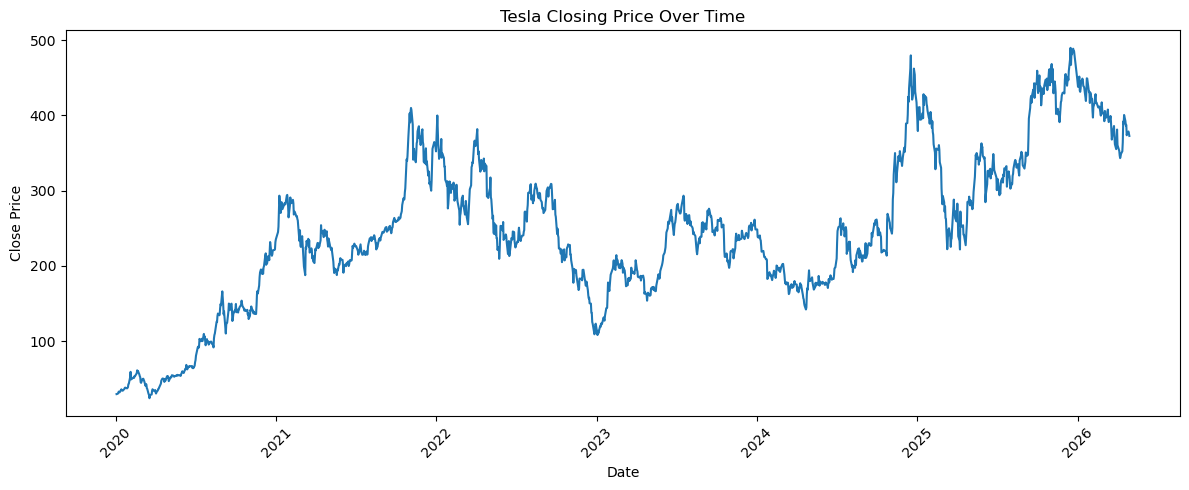

In [20]:
plt.figure(figsize=(12, 5))
plt.plot(merged_df["Date"], merged_df["Close"])
plt.title("Tesla Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Visualize Tesla News Activity

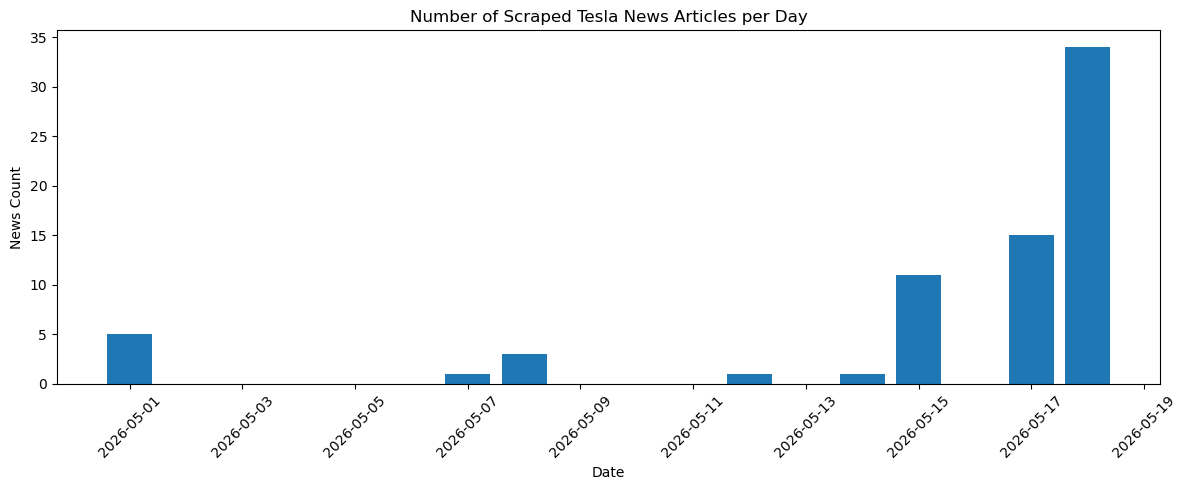

In [21]:
plt.figure(figsize=(12, 5))
plt.bar(news_count_df["date"], news_count_df["news_count"])
plt.title("Number of Scraped Tesla News Articles per Day")
plt.xlabel("Date")
plt.ylabel("News Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()